Number of examples retained:
  5850 (training)
  3150 (validation)
  1500 (test)
--> Initializing and Training Standard Backprop Models...
Training MLP (Backprop)...
Training SNN (Backprop)...

--> Initializing and Training Feedback Alignment Models...
Training MLP (Feedback Alignment)...
Training SNN (Feedback Alignment)...


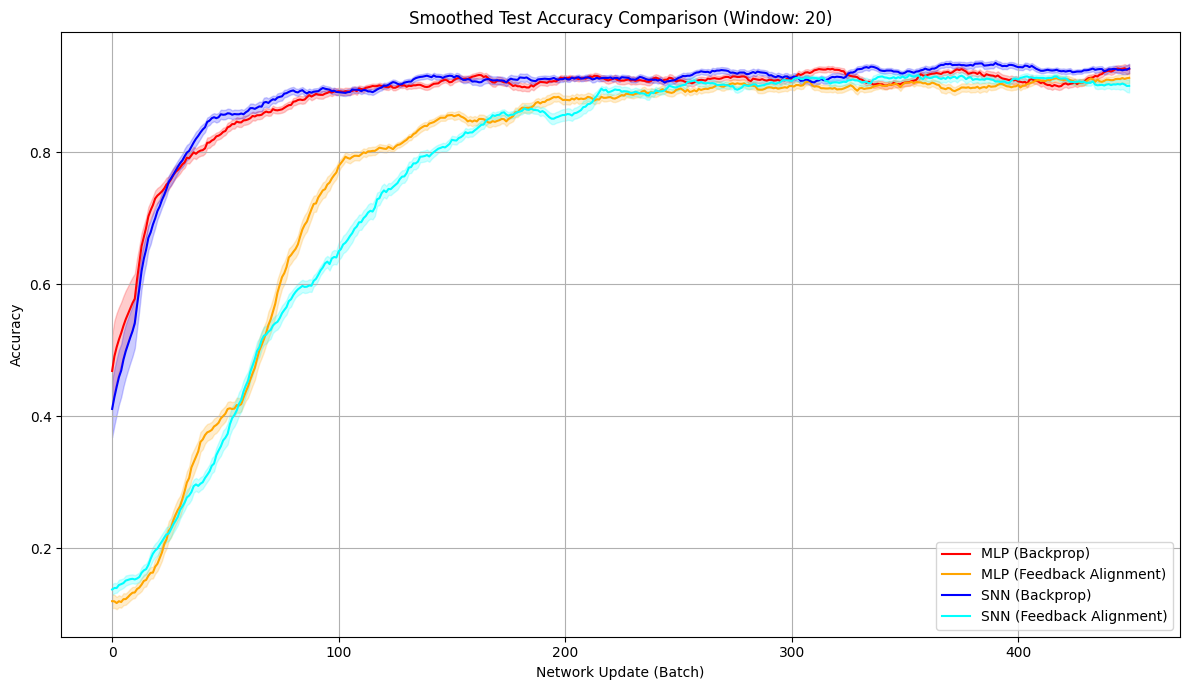

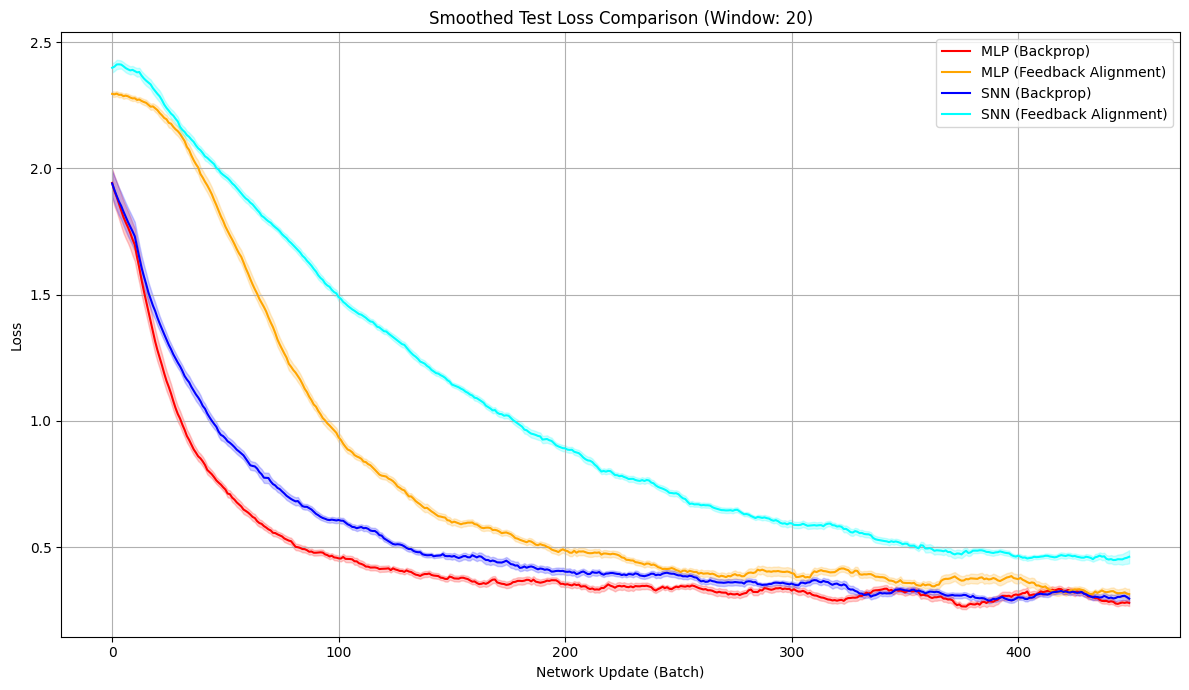

In [2]:
import os
import io
import math
import random
import contextlib
import numpy as np
import scipy
import warnings
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# IPython dependencies (if running in a notebook)
try:
    from IPython.display import Image, SVG, display
except ImportError:
    pass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 10 # Speed up training
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 10
        self.NUM_HIDDEN = 100
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.8 # Slope for leaky relu on SNN
        self.NUM_SNN_TIMESTEPS = 25

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 3e-4

config = Config()

def download_mnist(train_prop=0.8, keep_prop=0.5, neuromatch_magic_normalize = 1):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    if neuromatch_magic_normalize:
        norm_func = transforms.Normalize((0.1307,), (0.3081,))
    else:
        norm_func = transforms.Normalize((0,), (1,))

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              norm_func
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )

    print("Number of examples retained:")
    print(f"  {len(train_set)} (training)")
    print(f"  {len(valid_set)} (validation)")
    print(f"  {len(test_set)} (test)")

    return train_set, valid_set, test_set

train_set, valid_set, test_set = download_mnist(train_prop=0.65, keep_prop=0.15, neuromatch_magic_normalize = 1)

BATCH_SIZE = config.BATCH_SIZE
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS, activation_type="leaky", bias=False):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_outputs = num_outputs
        self.bias = bias

        self.lin1 = torch.nn.Linear(num_inputs, num_hidden, bias=bias)
        self.lin2 = torch.nn.Linear(num_hidden, num_outputs, bias=bias)
        self.activation = torch.nn.LeakyReLU(config.BETA)

    def forward(self, X, y=None):
        h = self.activation(self.lin1(X.reshape(-1, self.num_inputs)))
        y_pred = self.lin2(h)
        return y_pred

class SNN_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.Leaky(beta=config.BETA)
        self.fc2 = nn.Linear(config.NUM_HIDDEN, config.NUM_OUTPUTS)
        self.lif2 = snn.Leaky(beta=config.BETA)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec, mem2_rec = [], []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

class FALinearFunction(torch.autograd.Function):
    """
    Custom autograd function for Feedback Alignment.
    Forward pass acts as a normal Linear layer.
    Backward pass uses a fixed random matrix B to propagate gradients.
    """
    @staticmethod
    def forward(ctx, input, weight, bias, B):
        # Save tensors for backward pass
        ctx.save_for_backward(input, weight, bias, B)
        output = input.mm(weight.t())
        if bias is not None:
            output += bias.unsqueeze(0).expand_as(output)
        return output
    @staticmethod
    def backward(ctx, grad_output):
        input, weight, bias, B = ctx.saved_tensors
        grad_input = grad_weight = grad_bias = grad_B = None
        # Feedback Alignment Gradient transport
        if ctx.needs_input_grad[0]:
            # Instead of grad_output.mm(weight), we use the fixed matrix B
            grad_input = grad_output.mm(B)
        if ctx.needs_input_grad[1]:
            # Weight update rules remain purely local and standard
            grad_weight = grad_output.t().mm(input)
        if bias is not None and ctx.needs_input_grad[2]:
            grad_bias = grad_output.sum(0)
        # We return None for B because it does not require gradients
        return grad_input, grad_weight, grad_bias, None

class FALinear(nn.Module):
    """
    Feedback Alignment Linear Layer.
    Maintains a standard learned weight matrix and a fixed random matrix B.
    """
    def __init__(self, in_features, out_features, bias=True):
        super(FALinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_features))
        else:
            self.register_parameter('bias', None)
        # Fixed random matrix for Feedback Alignment (Not a learned parameter)
        self.register_buffer('B', torch.Tensor(out_features, in_features))
        self.reset_parameters()
    def reset_parameters(self):
        # Initialize standard weights
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)
        # Initialize B with fixed random weights
        nn.init.kaiming_uniform_(self.B, a=math.sqrt(5))
    def forward(self, input):
        return FALinearFunction.apply(input, self.weight, self.bias, self.B)

class FAMultiLayerPerceptron(torch.nn.Module):
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS, bias=False):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_outputs = num_outputs
        # We replace standard Linear layers with FALinear layers
        self.lin1 = FALinear(num_inputs, num_hidden, bias=bias)
        self.lin2 = FALinear(num_hidden, num_outputs, bias=bias)
        self.activation = torch.nn.LeakyReLU(config.BETA)
    def forward(self, X, y=None):
        h = self.activation(self.lin1(X.reshape(-1, self.num_inputs)))
        y_pred = self.lin2(h)
        return y_pred

class FASNN_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        # We replace standard Linear layers with FALinear layers
        self.fc1 = FALinear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.Leaky(beta=config.BETA)
        self.fc2 = FALinear(config.NUM_HIDDEN, config.NUM_OUTPUTS)
        self.lif2 = snn.Leaky(beta=config.BETA)
    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec, mem2_rec = [], []
        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)
        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)




def train_snn_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for SNNs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []
    num_steps = config.NUM_SNN_TIMESTEPS

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            spk_rec, mem_rec = model(data.view(config.BATCH_SIZE, -1))

            # Loss and updates
            loss_val = torch.zeros((1), dtype=torch.float, device=device)
            for step in range(num_steps):
                loss_val += criterion(mem_rec[step], targets)
            loss_val /= num_steps

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            _, predicted_train_labels = spk_rec.sum(dim=0).max(1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_spk, test_mem = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = torch.zeros((1), dtype=torch.float, device=device)
                for step in range(num_steps):
                     test_loss += criterion(test_mem[step], test_targets)
                test_loss /= num_steps
                test_loss_hist.append(test_loss.item())

                _, predicted_test_labels = test_spk.sum(dim=0).max(1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist


def train_mlp_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for MLPs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            y_pred = model(data.view(config.BATCH_SIZE, -1))

            # Loss and Updates
            loss_val = criterion(y_pred, targets)
            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            predicted_train_labels = torch.argmax(y_pred, dim=1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_y_pred = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = criterion(test_y_pred, test_targets)
                test_loss_hist.append(test_loss.item())

                predicted_test_labels = torch.argmax(test_y_pred, dim=1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist


# 1. Standard Backprop Models
print("--> Initializing and Training Standard Backprop Models...")
mlp_bp = MultiLayerPerceptron(num_hidden=config.NUM_HIDDEN, bias=config.BIAS).to(device)
snn_bp = SNN_MLP().to(device)

mlp_bp_optimizer = torch.optim.Adam(mlp_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
snn_bp_optimizer = torch.optim.Adam(snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

print("Training MLP (Backprop)...")
mlp_bp_loss, mlp_bp_tloss, mlp_bp_acc, mlp_bp_tacc = train_mlp_model(
    mlp_bp, mlp_bp_optimizer, train_loader, test_loader
)

print("Training SNN (Backprop)...")
snn_bp_loss, snn_bp_tloss, snn_bp_acc, snn_bp_tacc = train_snn_model(
    snn_bp, snn_bp_optimizer, train_loader, test_loader
)

# 2. Feedback Alignment Models
print("\n--> Initializing and Training Feedback Alignment Models...")
mlp_fa = FAMultiLayerPerceptron(num_hidden=config.NUM_HIDDEN, bias=config.BIAS).to(device)
snn_fa = FASNN_MLP().to(device)

mlp_fa_optimizer = torch.optim.Adam(mlp_fa.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
snn_fa_optimizer = torch.optim.Adam(snn_fa.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

print("Training MLP (Feedback Alignment)...")
mlp_fa_loss, mlp_fa_tloss, mlp_fa_acc, mlp_fa_tacc = train_mlp_model(
    mlp_fa, mlp_fa_optimizer, train_loader, test_loader
)

print("Training SNN (Feedback Alignment)...")
snn_fa_loss, snn_fa_tloss, snn_fa_acc, snn_fa_tacc = train_snn_model(
    snn_fa, snn_fa_optimizer, train_loader, test_loader
)



def smooth_curve_with_sem(data, window_size):
    """
    Computes a moving average and the Standard Error of the Mean (SEM)
    over a sliding window to generate smooth trendlines and shaded confidence regions.
    """
    if window_size <= 1:
        return np.array(data), np.zeros(len(data))
    if len(data) < window_size:
        return np.array([np.mean(data)] * len(data)), np.array([np.std(data)/np.sqrt(len(data))] * len(data))

    smoothed_data = []
    sem_data = []
    for i in range(len(data)):
        start_index = max(0, i - window_size // 2)
        end_index = min(len(data) - 1, i + window_size // 2)
        window = data[start_index:end_index + 1]

        smoothed_data.append(np.mean(window))
        sem_data.append(np.std(window) / np.sqrt(len(window)))

    return np.array(smoothed_data), np.array(sem_data)

SMOOTHING_WINDOW = 20

# Smoothing accuracies and computing SEM
sm_mlp_bp_tacc, sem_mlp_bp_tacc = smooth_curve_with_sem(mlp_bp_tacc, SMOOTHING_WINDOW)
sm_mlp_fa_tacc, sem_mlp_fa_tacc = smooth_curve_with_sem(mlp_fa_tacc, SMOOTHING_WINDOW)

sm_snn_bp_tacc, sem_snn_bp_tacc = smooth_curve_with_sem(snn_bp_tacc, SMOOTHING_WINDOW)
sm_snn_fa_tacc, sem_snn_fa_tacc = smooth_curve_with_sem(snn_fa_tacc, SMOOTHING_WINDOW)

# Smoothing losses and computing SEM
sm_mlp_bp_tloss, sem_mlp_bp_tloss = smooth_curve_with_sem(mlp_bp_tloss, SMOOTHING_WINDOW)
sm_mlp_fa_tloss, sem_mlp_fa_tloss = smooth_curve_with_sem(mlp_fa_tloss, SMOOTHING_WINDOW)

sm_snn_bp_tloss, sem_snn_bp_tloss = smooth_curve_with_sem(snn_bp_tloss, SMOOTHING_WINDOW)
sm_snn_fa_tloss, sem_snn_fa_tloss = smooth_curve_with_sem(snn_fa_tloss, SMOOTHING_WINDOW)

epochs_range = np.arange(len(sm_mlp_bp_tacc))

# Plot 1: Smoothed Test Accuracy Comparison Plot with SEM
plt.figure(figsize=(12, 7))

plt.plot(epochs_range, sm_mlp_bp_tacc, label='MLP (Backprop)', color='red')
plt.fill_between(epochs_range, sm_mlp_bp_tacc - sem_mlp_bp_tacc, sm_mlp_bp_tacc + sem_mlp_bp_tacc, color='red', alpha=0.2)

plt.plot(epochs_range, sm_mlp_fa_tacc, label='MLP (Feedback Alignment)', color='orange')
plt.fill_between(epochs_range, sm_mlp_fa_tacc - sem_mlp_fa_tacc, sm_mlp_fa_tacc + sem_mlp_fa_tacc, color='orange', alpha=0.2)

plt.plot(epochs_range, sm_snn_bp_tacc, label='SNN (Backprop)', color='blue')
plt.fill_between(epochs_range, sm_snn_bp_tacc - sem_snn_bp_tacc, sm_snn_bp_tacc + sem_snn_bp_tacc, color='blue', alpha=0.2)

plt.plot(epochs_range, sm_snn_fa_tacc, label='SNN (Feedback Alignment)', color='cyan')
plt.fill_between(epochs_range, sm_snn_fa_tacc - sem_snn_fa_tacc, sm_snn_fa_tacc + sem_snn_fa_tacc, color='cyan', alpha=0.2)

plt.title(f'Smoothed Test Accuracy Comparison (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Smoothed Test Loss Comparison Plot with SEM
plt.figure(figsize=(12, 7))

plt.plot(epochs_range, sm_mlp_bp_tloss, label='MLP (Backprop)', color='red')
plt.fill_between(epochs_range, sm_mlp_bp_tloss - sem_mlp_bp_tloss, sm_mlp_bp_tloss + sem_mlp_bp_tloss, color='red', alpha=0.2)

plt.plot(epochs_range, sm_mlp_fa_tloss, label='MLP (Feedback Alignment)', color='orange')
plt.fill_between(epochs_range, sm_mlp_fa_tloss - sem_mlp_fa_tloss, sm_mlp_fa_tloss + sem_mlp_fa_tloss, color='orange', alpha=0.2)

plt.plot(epochs_range, sm_snn_bp_tloss, label='SNN (Backprop)', color='blue')
plt.fill_between(epochs_range, sm_snn_bp_tloss - sem_snn_bp_tloss, sm_snn_bp_tloss + sem_snn_bp_tloss, color='blue', alpha=0.2)

plt.plot(epochs_range, sm_snn_fa_tloss, label='SNN (Feedback Alignment)', color='cyan')
plt.fill_between(epochs_range, sm_snn_fa_tloss - sem_snn_fa_tloss, sm_snn_fa_tloss + sem_snn_fa_tloss, color='cyan', alpha=0.2)

plt.title(f'Smoothed Test Loss Comparison (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()